[colab에서 실행하기](https://colab.research.google.com/github/science-odysseia/AILearning/blob/main/AI_08.ipynb)

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def auto_tick_step(vmin, vmax):
    span = abs(vmax - vmin)
    if span <= 2: return 0.2
    if span <= 10: return 1
    return 2

def geogebra_style(func, x_range=(-5, 5), y_range=(-0.1, 1.1), x_step=None, y_step=None):
    x = np.linspace(x_range[0], x_range[1], 1000)
    y = func(x)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, y, linewidth=3, color='#1E88E5', zorder=3) # 그래프가 격자 위로 오도록 zorder 설정

    # 축 설정 (원점 기준)
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    # ===== 눈금 간격 결정 (직접 입력값 vs 자동 계산) =====
    final_x_step = x_step if x_step else auto_tick_step(*x_range)
    final_y_step = y_step if y_step else auto_tick_step(*y_range)

    # 주 눈금 (숫자 표시)
    xticks = np.arange(x_range[0], x_range[1] + final_x_step, final_x_step)
    yticks = np.arange(y_range[0], y_range[1] + final_y_step, final_y_step)
    
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # 보조 눈금 (격자용, 주 눈금의 절반)
    ax.set_xticks(np.arange(x_range[0], x_range[1], final_x_step/2), minor=True)
    ax.set_yticks(np.arange(y_range[0], y_range[1], final_y_step/2), minor=True)

    # 격자 디자인
    ax.grid(which='major', linewidth=1.2, color='#cfd8dc', alpha=0.8)
    ax.grid(which='minor', linewidth=0.5, color='#eceff1', alpha=0.5)
    ax.set_axisbelow(True) # 격자를 그래프 뒤로

    # 비율 및 범위
    ax.set_aspect('auto')
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()


시그모이드 함수 : 

$$
f(x) = \frac{1}{1+e^{-x}}
$$

그래프는 아래 코드를 실행시킨 결과와 같습니다.

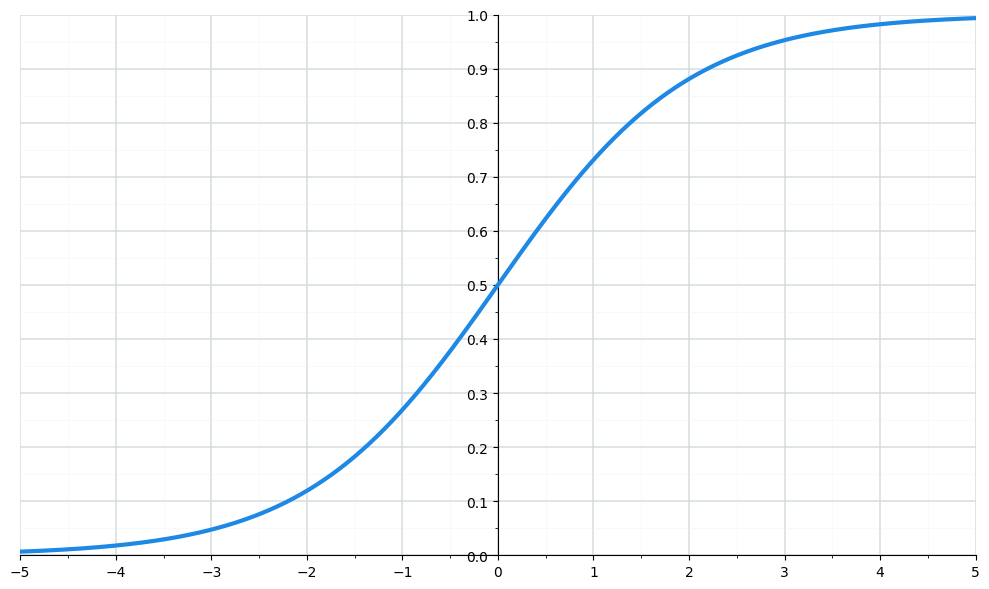

In [34]:
import torch
geogebra_style(lambda x : 1/(1 + np.exp(-x)), (-5, 5), (0, 1), 1, 0.1)

이진 분류에서 주로 사용하는 활성화 함수 중 하나로

입력값 x가 어떤 값이 나와도 0 - 1사이 확률값으로 변환 가능합니다.


## 1. 이진 분류 실습 : iris 데이터 분류하기

데이터 내용 확인해보기

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# iris 데이터 불러오기
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# 정답 라벨 추가 ( [0 : setosa] [1 : versicolor] [2 : virginica] )
df['target'] = iris.target
print(df)
print("target : ", end ='')
for i, v in enumerate(iris.target_names):
    print(f"[{i} : {v}]", end = ' ')

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
0         0  

이진 분류를 위해, 두 종류의 꽃 데이터(100개)와 두 개의 특징(꽃받침 길이/너비)만 사용합니다.

target : 0, 1(총 100개의 데이터)

`sepal_length`, `sepal_width`만 활용예정.

In [27]:
x_data = iris.data[:100, :2]
y_data = iris.target[:100]

이제 이 데이터를 훈련 데이터와 테스트 데이터로 분류합니다.

여기서는 100개의 데이터를

훈련 데이터 70개, 테스트 데이터 30개로 분할합니다.

이 과정은 모두 랜덤 순서에 의해 결정됩니다.

In [32]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, train_size=70, test_size=30, random_state=42)

입력 차원은 `sepal_length`, `sepal_width` 2개가 됩니다.

우리가 원하는 결과는 `target = 0`인지, `target = 1`인지 이므로

1을 기준으로 하면

출력은 `target = 1일 확률`, 즉 출력 차원은 1개가 됩니다.

이제 신경망 클래스를 정의해봅시다.

In [ ]:
# --- 2. 모델 클래스 정의 ---
# 2입력 1출력 로지스틱 회귀 모델
import torch, torch.nn as nn

class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()  # 상속
        self.l1 = nn.Linear(n_input, n_output) # 선형함수 사용
        self.sigmoid = nn.Sigmoid() # 시그모이드 사용(통과)

        # 가중치와 편향을 1로 초기화합니다.
        # (일반적인 경우에는 무작위 값으로 초기화합니다.)
        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)

    # 데이터가 모델을 통과하는 흐름(순전파)을 정의합니다. (예측 함수 정의)
    def forward(self, x):
        x1 = self.l1(x) # 선형 함수 적용
        x2 = self.sigmoid(x1) # 시그모이드 함수 적용
        return x2

<img src="https://github.com/science-odysseia/AILearning/blob/main/imgs/Linear1.png?raw=true" width="500">

위 코드의 클래스 구조를 간단히 그려본 그림입니다.

위 그림을 보면서 코드 내용을 분석해 봅시다.

``` python
class Net(nn.Module):
```
Net 이라는 신경망 클래스를 정의한 부분입니다.

nn.Module로부터 상속받게 하여 여러가지 기능들을 이용하는 것이 목적입니다.

대표적으로 
- 파라미터(W(weight), B(bias)) 자동관리
- 학습모드 설정(train(훈련모드), eval(테스트모드))
- GPU/CPU 장치 이용
- forward 매서드 활용

등의 기능들이 있습니다.

<br>

``` python
def __init__(self, n_input, n_output)
```

클래스의 생성자 부분입니다.

`n_input`을 통해 입력 차원 수를, `n_output`을 통해 출력 차원 수를 정의하겠다는 내용입니다.

<br>

``` python
super().__init__()
```
부모 클래스 생성자 실행 명령어입니다.

<br>

``` python
self.l1 = nn.Linear(n_input, n_output)
```

위 그림에서 나오는 신경망 구조를 `l1`이라는 이름으로 만들겠다는 내용입니다.

입력 차원은 `n_input`, 출력 차원은 `n_output`이 되겠습니다.

속성으로는 weight, bias가 대표적으로 있습니다.

$$
Y = WX + B
$$

입력값들이 주어질 때, 여기에 어떤 값들을 곱할 건지를 정하는 `가중치`들이 모인 배열을 weight($W$),

그리고 곱해진 값들에 얼마를 더할 건지를 정하는 `편향`들이 모인 배열을 bias($B$) 라고 합니다.



<br>

```python
self.sigmoid = nn.Sigmoid()
```

시그모이드 함수 `sigmoid`를 만들겠다는 내용입니다.

<br>

``` python
self.l1.weight.data.fill_(1.0)
self.l1.bias.data.fill_(1.0)

```
연산을 하기 위해서는 뭐든지 초기값이 있어야 연산을 시작할 수 있습니다.

weight, bias의 모든 값을 1로 초기화해주는 코드입니다.

<br>

``` python
def forward(self, x)
```

$$
Y = WX + B
$$

입력값 배열 `x`가 주어질 때 위 식에 따라 연산하여 결과값 배열을 출력하는 함수입니다.

<br>

``` python
x1 = self.l1(x)
x2 = self.sigmoid(x1)
return x2
```

linear층을 계산한 출력값 x1을 sigmoid하여 나온 출력값 x2를 반환하는 함수입니다.
